# Oil Price & Geopolitical Events - EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

client = bigquery.Client(project='module-2-project-490315')
sns.set_theme(style='darkgrid')
print('Connected to BigQuery')

/home/rakhi/miniconda3/envs/meltano-env/lib/python3.11/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Connected to BigQuery


In [2]:
# Load mart table
df = client.query('''
    SELECT * FROM `module-2-project-490315.oil_pipeline_raw.mart_oil_geopolitics`
    ORDER BY date
''').to_dataframe()
df['date'] = pd.to_datetime(df['date'])
print(df.shape)
df.head()

/home/rakhi/miniconda3/envs/meltano-env/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(4047, 11)


,date,brent_price,wti_price,dxy_index,vix,gpr_index,brent_return,wti_return,event_type,event_description,event_severity
0,2010-02-17,76.269997,77.330002,80.379997,21.719999,80.725357,0.007796,0.004155,None,None,<NA>
1,2010-02-18,77.779999,79.059998,80.400002,20.629999,80.725357,0.019798,0.022372,None,None,<NA>
2,2010-02-19,78.190002,79.809998,80.639999,20.020000,80.725357,0.005271,0.009486,None,None,<NA>
3,2010-02-22,78.610001,80.160004,80.510002,19.940001,80.725357,0.005372,0.004385,None,None,<NA>
4,2010-02-23,77.250000,78.860001,80.849998,21.370001,80.725357,-0.017301,-0.016218,None,None,<NA>


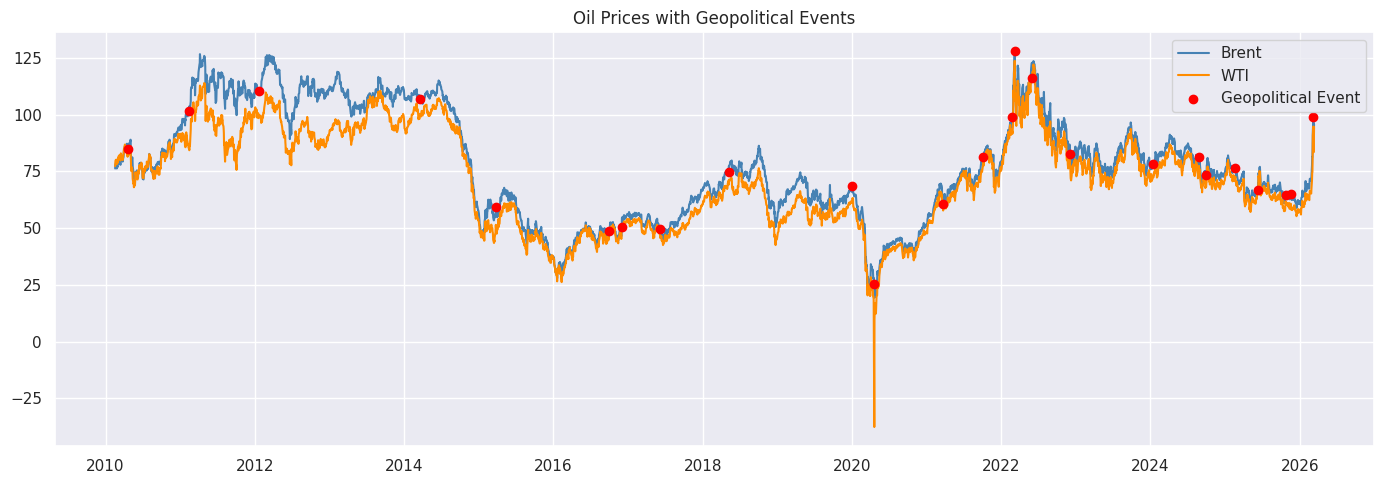

In [4]:
# Brent & WTI prices over time
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['date'], df['brent_price'], label='Brent', color='steelblue')
ax.plot(df['date'], df['wti_price'], label='WTI', color='darkorange')
events = df[df['event_type'].notna()]
ax.scatter(events['date'], events['brent_price'], color='red', zorder=5, label='Geopolitical Event')
ax.set_title('Oil Prices with Geopolitical Events')
ax.legend()
plt.tight_layout()
plt.show()

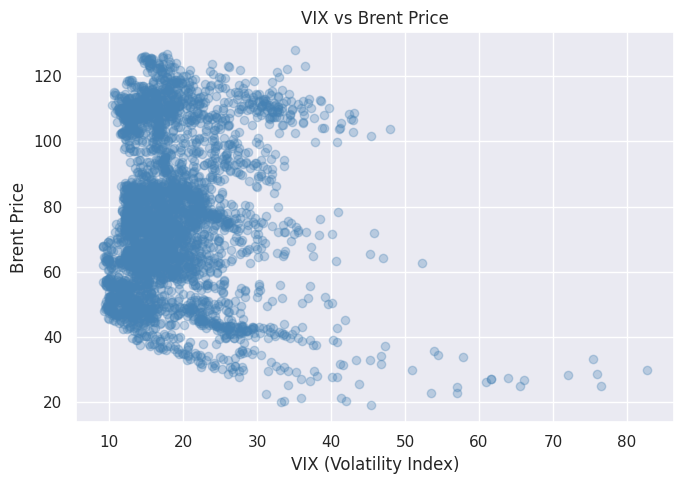

In [5]:
# VIX vs Brent correlation
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['vix'], df['brent_price'], alpha=0.3, color='steelblue')
ax.set_xlabel('VIX (Volatility Index)')
ax.set_ylabel('Brent Price')
ax.set_title('VIX vs Brent Price')
plt.tight_layout()
plt.show()

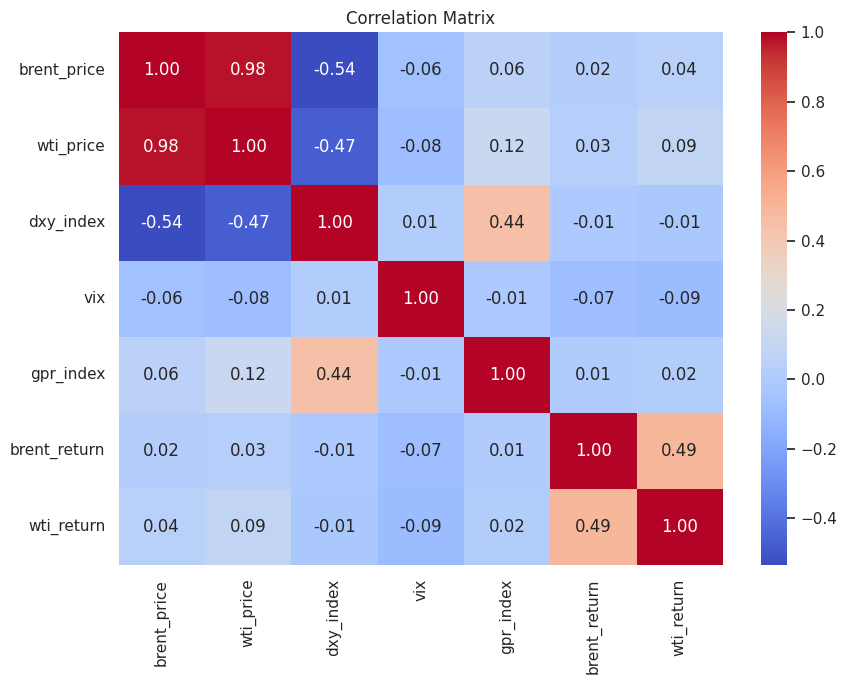

In [6]:
# Correlation heatmap
cols = ['brent_price', 'wti_price', 'dxy_index', 'vix', 'gpr_index', 'brent_return', 'wti_return']
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Finding 4: GPR Index Leads Price Spikes

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(df['date'], df['brent_price'], color='steelblue', label='Brent Price')
ax1.set_ylabel('Brent Price (USD)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2 = ax1.twinx()
ax2.plot(df['date'], df['gpr_index'], color='red', alpha=0.6, label='GPR Index')
ax2.set_ylabel('GPR Index', color='red')
ax2.tick_params(axis='y', labelcolor='red')
events = df[df['event_type'].notna()]
ax1.scatter(events['date'], events['brent_price'], color='black', zorder=5, s=40, label='Event')
ax1.set_title('Finding 4: GPR Index vs Brent Price — GPR Leads Price Spikes')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()

## Finding 5: DXY Inverse Relationship

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(df['date'], df['brent_price'], color='steelblue', label='Brent Price')
ax1.set_ylabel('Brent Price (USD)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2 = ax1.twinx()
ax2.plot(df['date'], df['dxy_index'], color='darkorange', alpha=0.7, label='DXY Index')
ax2.set_ylabel('DXY Index', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax1.set_title('Finding 5: DXY vs Brent Price — Inverse Relationship')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()
corr = df['dxy_index'].corr(df['brent_price'])
print(f'DXY vs Brent correlation: {corr:.3f}')

## Finding 6: Return Volatility Clustering Around Events

In [ ]:
df['year'] = df['date'].dt.year
df['abs_brent_return'] = df['brent_return'].abs()
yearly = df.groupby('year').agg(
    avg_volatility=('abs_brent_return', 'mean'),
    event_count=('event_type', lambda x: x.notna().sum())
).reset_index()
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(yearly['year'], yearly['avg_volatility'], color='steelblue', alpha=0.7, label='Avg |Return|')
ax1.set_ylabel('Average Absolute Return', color='steelblue')
ax1.set_xlabel('Year')
ax2 = ax1.twinx()
ax2.plot(yearly['year'], yearly['event_count'], color='red', marker='o', linewidth=2, label='Event Count')
ax2.set_ylabel('Geopolitical Event Count', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax1.set_title('Finding 6: Return Volatility Clustering Around Geopolitical Events')
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
plt.tight_layout()
plt.show()